In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import datetime as dt
import math

In [38]:
data_file = pd.read_csv("Bonneville_Salt_Flat_08_05_2025_logs.csv")
car_park = pd.read_csv("08_04_2025_logs.csv")
data_file
# data_file = pd.read_excel("")

,Solar Panel Time (sec),Solar Panel Timestamp,Solar Panel Voltage,Solar Panel Current,Power Output Calculated,Solar Panel Power Output,Unnamed: 6,Telescope Timestamp Start,Telescope Timestamp End,Azimuth (deg),Altitude (deg),Gamma (deg),cos(Gamma)
0,215,12:29:43 PM,130,115,14.950,15,NaN,12:29:45,12:30:45,0.0000,61.4800,0.0,1.000000
1,220,12:29:48 PM,131,114,14.934,15,NaN,12:31:16,12:32:16,50.4094,49.5466,30.0,0.866033
2,225,12:29:53 PM,131,114,14.934,15,NaN,12:32:40,12:33:40,74.5883,26.0608,60.0,0.500027
3,230,12:29:58 PM,131,114,14.934,15,NaN,12:34:01,12:35:01,90.0000,0.0000,90.0,0.000046
4,235,12:30:03 PM,131,114,14.934,15,NaN,12:35:22,12:36:22,105.4117,-26.0608,120.0,-0.499947
...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,2457,2:33:13 PM,136,36,4.896,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
689,2462,2:33:18 PM,136,36,4.896,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690,2467,2:33:23 PM,136,36,4.896,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
691,2472,2:33:28 PM,136,36,4.896,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# print(solar_panel_timestamp[0])
solar_panel_timestamp = data_file['Solar Panel Timestamp']# Clean data
solar_panel_power = data_file['Power Output Calculated']# Clean data
solar_panel_voltage = data_file['Solar Panel Voltage']# Clean data
solar_panel_current = data_file['Solar Panel Current']# Clean data


telescope_timestamp = data_file['Telescope Timestamp Start']
telescope_timestamp_end = data_file['Telescope Timestamp End']
#remove NaT values form time stamp
telescope_timestamp = telescope_timestamp[telescope_timestamp.notna()]
gamma = data_file['Gamma (deg)']
gamma = gamma[gamma.notna()]
cos_gamma = data_file['cos(Gamma)']
altitude = data_file['Altitude (deg)']

carpark_solar_timestamp = car_park['Solar Panel Timestamp']# Clean data
carpark_solar_power = car_park['Power Output Calculated']# Clean data
carpark_telescope_timestamp = car_park['Telescope Timestamp Start'][0:35]
carpark_telescope_timestamp_end = car_park['Telescope Timestamp End'][0:35]
carpark_gamma = car_park['Gamma (deg)'][0:35]

35
35


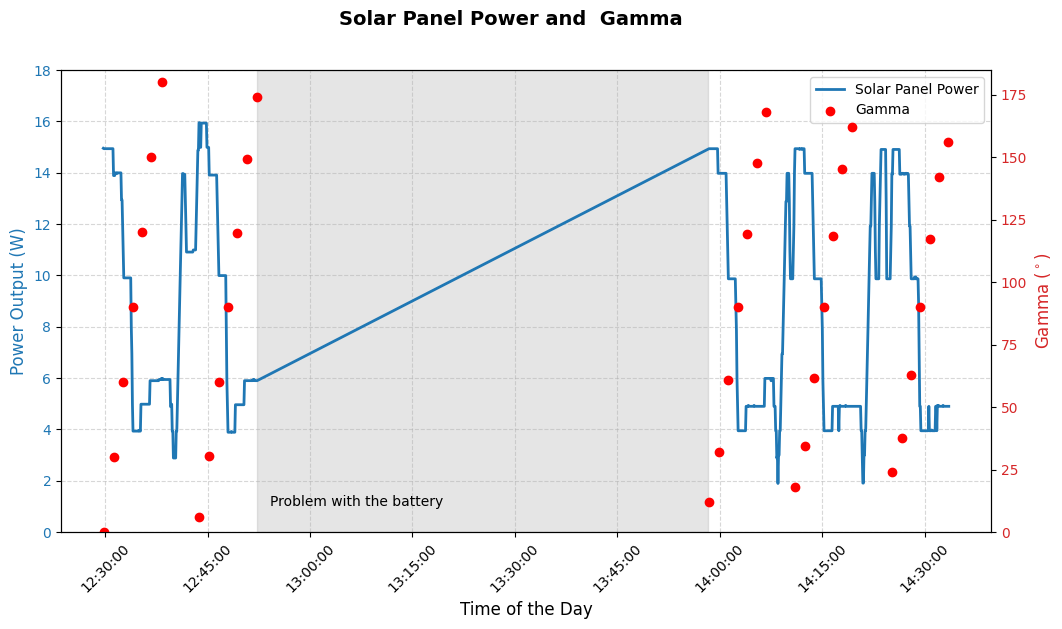

In [40]:
solar_panel_timestamp_datetime = []
for time_string in solar_panel_timestamp:
    time_datetime = dt.datetime.strptime(time_string, "%I:%M:%S %p").time()
    solar_panel_timestamp_datetime.append(time_datetime)

telescope_timestamp_datetime = []
for time_string in telescope_timestamp:
    time_datetime = dt.datetime.strptime(time_string, "%H:%M:%S").time()
    telescope_timestamp_datetime.append(time_datetime)

telescope_timestamp_end_datetime = []
for time_string in telescope_timestamp_end:
    # Check if the value is a float (like NaN) or not a string
    if isinstance(time_string, float) or not time_string:
        # Using None (or np.nan) keeps your list aligned with your original data rows
        telescope_timestamp_end_datetime.append(None) 
    else:
        time_datetime = dt.datetime.strptime(time_string, "%H:%M:%S").time()
        telescope_timestamp_end_datetime.append(time_datetime)


base_date = dt.datetime(2025, 8, 5)
solar_panel_datetime = [dt.datetime.combine(base_date.date(), t) for t in solar_panel_timestamp_datetime]
telescope_datetime = [dt.datetime.combine(base_date.date(), t) for t in telescope_timestamp_datetime]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Solar Panel Power

ax1.plot(solar_panel_datetime, solar_panel_power, color='tab:blue', label='Solar Panel Power', linewidth=2)
ax1.set_ylabel("Power Output (W)", color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time of the Day", fontsize=12)
ax1.set_ylim(0, 18)
#Fill the gap between 12:52 to 12:58
ax1.axvspan(dt.datetime(2025, 8, 5,12,52,10), dt.datetime(2025, 8, 5,13,58,20), color='gray', alpha=0.2)
#Write the text in that fill area
ax1.text(dt.datetime(2025, 8, 5,12,54,10),1,'Problem with the battery')

# Format the x-axis as time (HH:MM)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

print(len(telescope_datetime))
print(len(gamma))

# Create second axis for Gamma
ax2 = ax1.twinx()
ax2.scatter(telescope_datetime, gamma, color='red', label='Gamma')
ax2.set_ylabel(r"Gamma ($^\circ$)", color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 185)

# Add grid, title, and legends
ax1.grid(True, linestyle='--', alpha=0.5)
fig.suptitle("Solar Panel Power and  Gamma", fontsize=14, weight='bold')
# fig.tight_layout(rect=[0, 0, 1, 0.95])

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.show()





In [41]:
from scipy.optimize import curve_fit


# Create dataframes and remove NaT / NaNs
solar_df = pd.DataFrame({
    'solar_start_time': solar_panel_timestamp_datetime,
    'power': solar_panel_power
}).dropna()
print(len(telescope_timestamp_datetime))
print(len(telescope_timestamp_end))
print(len(gamma))
print(len(altitude))

telescope_df = pd.DataFrame({
    'scope_start_time': telescope_timestamp_datetime,
    'scope_end_time': telescope_timestamp_end,
    'gamma': gamma,
    'altitude': altitude
}).dropna()
#Remove nan from solar_df

# Create dataframes and remove NaT / NaNs
carpark_solar_df = pd.DataFrame({
    'solar_start_time': carpark_solar_timestamp,
    'power': carpark_solar_power
}).dropna()

carpark_telescope_df = pd.DataFrame({
    'scope_start_time': carpark_telescope_timestamp,
    'scope_end_time': carpark_telescope_timestamp_end,
    'gamma': carpark_gamma,
    # 'altitude': carpark_altitude
}).dropna()
#Remove nan from solar_df

base_date = dt.datetime(2025, 8, 5)




solar_panel_datetime = [dt.datetime.combine(base_date.date(), t) for t in solar_df['solar_start_time']]
telescope_datetime = [dt.datetime.combine(base_date.date(), t) for t in telescope_df['scope_start_time']]
# telescope_datetime = pd.to_datetime(telescope_datetime)
# solar_panel_datetime = pd.to_datetime(solar_panel_datetime)

carpark_solar_panel_datetime = [base_date + t for t in carpark_solar_df['solar_start_time']]
carpark_telescope_datetime = [base_date + t for t in carpark_telescope_df['scope_start_time']]
# carpark_telescope_datetime = pd.to_datetime(carpark_telescope_datetime)
# carpark_solar_panel_datetime = pd.to_datetime(carpark_solar_panel_datetime)
print('carpark_telescope_datetime:', carpark_telescope_datetime)
print('telescope_datetime:',telescope_datetime)





35
693
35
693


ValueError: array length 35 does not match index length 693